## ÉTAPE 1 :  Importer les bibliothèques

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from tensorflow.keras.models import load_model
from PIL import Image

## ÉTAPE 2 : Charger le dataset

In [4]:
df = pd.read_csv("fer2013.csv")
print(df.head())

   emotion                                             pixels     Usage
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...  Training
1        0  151 150 147 155 148 133 111 140 170 174 182 15...  Training
2        2  231 212 156 164 174 138 161 173 182 200 106 38...  Training
3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...  Training
4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...  Training


In [5]:
print(df.shape)

(35887, 3)


## valeurs manquantes

In [6]:
print(df.isnull().sum())

emotion    0
pixels     0
Usage      0
dtype: int64


## ÉTAPE 3 : Préparer les données

In [7]:
pixels = df['pixels'].tolist()

images = []
for pixel_sequence in pixels:
    img = np.array(pixel_sequence.split(), dtype='float32')
    img = img.reshape(48,48)
    images.append(img)

X = np.array(images)
y = df['emotion'].values

## ÉTAPE 4 : Normalisation

In [8]:
X = X / 255.0

## ÉTAPE 5 : Ajouter dimension (channel)

In [9]:
X = X.reshape(-1, 48, 48, 1)

## ÉTAPE 6 : SPLIT Labels

In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

## ÉTAPE 7: Vérifier shapes

In [11]:
print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print("Val:", X_val.shape, y_val.shape)

Train: (28709, 48, 48, 1) (28709,)
Test: (3589, 48, 48, 1) (3589,)
Val: (3589, 48, 48, 1) (3589,)


## ÉTAPE 8 : Visualiser une image 

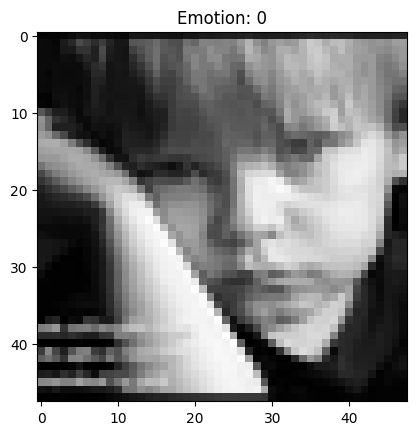

In [12]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0].reshape(48,48), cmap='gray')
plt.title(f"Emotion: {np.argmax(y_train[0])}")
plt.show()

In [13]:
duplicates = df.duplicated(subset='pixels').sum()
print("Nombre de duplicata :", duplicates)

Nombre de duplicata : 1853


## Class Weights

In [14]:
class_weights_values = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {i: class_weights_values[i] for i in range(len(class_weights_values))}

## (Data Augmentation)

In [15]:
datagen = ImageDataGenerator(
    rotation_range=25,
    zoom_range=0.25,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

## Créer le modèle CNN

In [16]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(256, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(256, activation='relu'))  # au lieu de 128
model.add(Dropout(0.6))

model.add(Dense(7, activation='softmax'))

c:\Users\Lenovo\anaconda3\envs\pfa_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## compile


In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Callbacks

In [ ]:
#early_stop = EarlyStopping(patience=7, restore_best_weights=True)

#lr_scheduler = ReduceLROnPlateau(
#    monitor='val_loss',
#    factor=0.5,
#    patience=3,
#    min_lr=1e-6
#)

## Entraîner avec Data Augmentation

In [ ]:
early_stop = EarlyStopping(, restore_best_weights=True)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),  # 🔥 important
    steps_per_epoch=len(X_train)//32,
    validation_data=(X_val, y_val),
    epochs=40,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/40
897/897 ━━━━━━━━━━━━━━━━━━━━ 117s 130ms/step - accuracy: 0.3926 - loss: 1.5739 - val_accuracy: 0.4338 - val_loss: 1.4614
Epoch 2/40
897/897 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4375 - loss: 1.3746 - val_accuracy: 0.4333 - val_loss: 1.4602
Epoch 3/40
897/897 ━━━━━━━━━━━━━━━━━━━━ 101s 113ms/step - accuracy: 0.3939 - loss: 1.5495 - val_accuracy: 0.4427 - val_loss: 1.4424
Epoch 4/40
897/897 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.3750 - loss: 1.5249 - val_accuracy: 0.4439 - val_loss: 1.4435
Epoch 5/40
897/897 ━━━━━━━━━━━━━━━━━━━━ 103s 114ms/step - accuracy: 0.4135 - loss: 1.5131 - val_accuracy: 0.4361 - val_loss: 1.4464
Epoch 6/40
897/897 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4375 - loss: 1.2345 - val_accuracy: 0.4408 - val_loss: 1.4348
Epoch 7/40
897/897 ━━━━━━━━━━━━━━━━━━━━ 97s 108ms/step - accuracy: 0.4132 - loss: 1.5140 - val_accuracy: 0.4645 - val_loss: 1.4063
Epoch 8/40
897/897 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4375 - loss: 1.5573 - v

In [21]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.5219 - loss: 1.2504
Test Accuracy: 0.5218724012374878


In [22]:
model.save("emotion_model.h5")

In [23]:
import sys
print(sys.executable)

c:\Users\Lenovo\anaconda3\envs\pfa_env\python.exe


In [27]:
import base64

with open("WIN_20260424_10_34_59_Pro.jpg", "rb") as image_file:
    encoded_string = base64.b64encode(image_file.read()).decode("utf-8")

print(encoded_string)

...
